In [17]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o", temperature=0.01)
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ad98c18a04', 'id': 'chatcmpl-D7hFyekI09jNmM37kbKWza3ApNlPI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c478c-f2d5-7ef3-a96b-521ee3a4c98a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [18]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
        주석에 있는 'ad_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다.)
    """
    messages: Annotated[list[str], add_messages]

graph_builder = StateGraph(State)

In [19]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재 시각 {now}'
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"

@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    
    Args:
        query(str): 검색어
        search_period(str): 검색 기간(e.g., 'w' for past week(default), 'm' for past month, 'y' for past year, 'd' for past day)
    
    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator=';\n'
    )

    searched = search.invoke(query)

    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

tools = [get_current_time, get_web_search]

In [20]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재 시각 2026-02-10 21:35:46'

In [21]:
tools[1].invoke({"query": "파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m
1. snippet: Jan 30, 2026 · 코딩의 세계로 첫 발을 내딛는 여러분을 위한 완벽한 파이썬 입문 가이드! 2025년, 가장 인기 있는 프로그래밍 언어 중 하나인 파이썬 의 기초부터 활용법까지, 쉽고 재미있게 배우는 방법을 소개합니다., title: 파이썬 프로그래밍 첫걸음: 초보자를 위한 파이썬 기초 완벽 가이드, link: https://saltstar8907.tistory.com/490
2. snippet: Jan 30, 2026 · 그렇다면 파이썬 공부 가 좋은 출발점이 될 수 있습니다. 파이썬 은 문법이 간결하고 읽기 쉬워서 처음 배우는 분들도 금방 익숙해질 수 있는 언어입니다. 이 글에서는 완전 초보자도 따라갈 수 있도록 파이썬 공부 방법을 단계별로 정리해드립니다., title: 파이썬 공부 시작하는 법, 초보자 입문부터 실무까지 6단계 정리, link: https://unsehub.com/파이썬-공부-시작하는-법-초보자-입문부터-실무까지-6/
3. snippet: Jan 30, 2026 · 점프 투 파이썬 과 함께하는 파이썬 입문용 코딩 기초 강의로 프로그래밍을 전혀 모르는 왕초보도 누구나 쉽게 코딩을 배울 수 있도록 강의를 진행 ... 1 day ago · Learn Python online: Python tutorials for developers of all skill levels, Python books and courses, Python news, code examples, articles, and more. Jan 22, 2026 · 파이썬 인강 학습을 제대로 활용하려면 몇 가지 전략이 필요합니다. 가장 중요한 건 꾸준함입니다. 매일 15분에서 30분이라도 정해진 시간에 학습하는 습관을 들이세요. Jan 19, 2026 · 파이썬 (Python)과 판다스 (Pandas) 라이브러리의 핵심적인 개념을 빠르게 익힐 수 있는 강의입니다. 각 파트 뒤에 있는 연습 문

'snippet: Jan 30, 2026 · 코딩의 세계로 첫 발을 내딛는 여러분을 위한 완벽한 파이썬 입문 가이드! 2025년, 가장 인기 있는 프로그래밍 언어 중 하나인 파이썬 의 기초부터 활용법까지, 쉽고 재미있게 배우는 방법을 소개합니다., title: 파이썬 프로그래밍 첫걸음: 초보자를 위한 파이썬 기초 완벽 가이드, link: https://saltstar8907.tistory.com/490;\nsnippet: Jan 30, 2026 · 그렇다면 파이썬 공부 가 좋은 출발점이 될 수 있습니다. 파이썬 은 문법이 간결하고 읽기 쉬워서 처음 배우는 분들도 금방 익숙해질 수 있는 언어입니다. 이 글에서는 완전 초보자도 따라갈 수 있도록 파이썬 공부 방법을 단계별로 정리해드립니다., title: 파이썬 공부 시작하는 법, 초보자 입문부터 실무까지 6단계 정리, link: https://unsehub.com/파이썬-공부-시작하는-법-초보자-입문부터-실무까지-6/;\nsnippet: Jan 30, 2026 · 점프 투 파이썬 과 함께하는 파이썬 입문용 코딩 기초 강의로 프로그래밍을 전혀 모르는 왕초보도 누구나 쉽게 코딩을 배울 수 있도록 강의를 진행 ... 1 day ago · Learn Python online: Python tutorials for developers of all skill levels, Python books and courses, Python news, code examples, articles, and more. Jan 22, 2026 · 파이썬 인강 학습을 제대로 활용하려면 몇 가지 전략이 필요합니다. 가장 중요한 건 꾸준함입니다. 매일 15분에서 30분이라도 정해진 시간에 학습하는 습관을 들이세요. Jan 19, 2026 · 파이썬 (Python)과 판다스 (Pandas) 라이브러리의 핵심적인 개념을 빠르게 익힐 수 있는 강의입니다. 각 파트 뒤에 있는 연습 문제를 함께 해결해 나가며 프로그래밍 역량을 향상시켜보세요!, title:

In [22]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x119909080>
get_web_search name='get_web_search' description="웹 검색을 수행하는 함수.\n\nArgs:\n    query(str): 검색어\n    search_period(str): 검색 기간(e.g., 'w' for past week(default), 'm' for past month, 'y' for past year, 'd' for past day)\n\nReturns:\n    str: 검색 결과" args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x119909e40>


In [23]:
model_with_tool = model.bind_tools(tools)

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.
    
    매개변수:
    state(State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
    
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리
        형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": model_with_tool.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [24]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name(dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)


In [25]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)

graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()

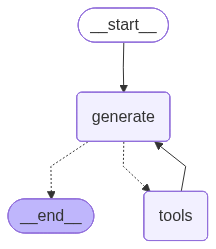

In [26]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [27]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇 시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

지금 서울의 시간은 2026년 2월 10일 21시 35분입니다.

AIMessageChunk(content='지금 서울의 시간은 2026년 2월 10일 21시 35분입니다.', additional_kwargs={}, response_metadata={'model_provider': 'openai', 'finish_reason': 'tool_callsstop', 'model_name': 'gpt-4o-2024-08-06gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ad98c18a04fp_ad98c18a04', 'service_tier': 'defaultdefault'}, id='lc_run--019c478d-033b-7233-9da6-21ef36bee2e8', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'Asia/Seoul', 'location': '서울'}, 'id': 'call_Q4MDbL44UUfFZLGik3swaRaT', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 362, 'output_tokens': 47, 'total_tokens': 409, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"timezone":"Asia/Seoul","location":"서울"}', 'id': 'call_Q4MDbL44UUfFZLGik3swaRaT', 'index': 0, 'type': 'tool_call_chunk'}], chunk_position='last')

In [28]:
from langchain_core.messages import AIMessageChunk, SystemMessage

about = "서울 월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
    너는 신문기자이다.
    최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.
    
    -최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심 있어 할만 한 주제를 선정하고, 왜 선정했는지 말해줘.
    - 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐.
    - 검색할 리스트를 토대로 재검색해.
    - 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해.
    - 검색된 결과는 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋아.
    
    더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성한다.
    제목, 부제, 리드문, 본문의 구성으로 작성한다. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
    """)]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        


-------- WEB SEARCH --------
서울 월드컵 경기장 잔디 문제
m
1. snippet: FC서울 역시 구단 소셜 미디어 (SNS)를 통해 "서울월드컵경기장 개최를 최우선으로 지속적으로 협의를 진행했다"며 "지난해 12월 코리아컵 및 ACLE 6차전 경기 후 잔디 복구가 이뤄지지 않은 상황에서 잔디 동결로 인한 선수단 부상, 관중 안전 문제 등의 ..., title: 꽁꽁 언 상암…Fc서울 Acle 홈 4차전 서울월드컵경기장 개최 불발 ..., link: https://www.sportsworldi.com/newsView/20260206511054
2. snippet: 다만 이번에는 잔디를 위해 서울이 한 발 물러섰다. 서울은 공식 성명에서 "지난 12월 코리아컵 및 ACLE 6차전 경기 후 잔디 복구가 이뤄지지 않은 상황에서 잔디 동결로 인한 선수단 부상, 관중 안전 문제 등의 이유로 서울월드컵경기장 대관이 불가함에 따라 대체 구장 물색을 포함한 종합적인 ..., title: [공식발표] Fc서울, Acle 8차전 서울월드컵경기장 아닌 목동종합 ..., link: http://www.footballist.co.kr/news/articleView.html?idxno=206675
3. snippet: 서울시와 서울시설공단이 서울월드컵경기장 잔디에 대한 긴급 복구 작업을 벌인다고 밝혔습니다. 이를 통해 오는 29일 열리는 FC서울 홈경기 전까지 잔디 상태를 정상화하겠다는 계획입니다. 시와 공단은 경기장 잔디 일부를 천연 잔디와 인조 잔디를 결합한 하이브리드 잔디로 교체하고, 잔디 밀도를 높이기 위한 작업도 이어갈 방침입니다...., title: 서울월드컵경기장, 잔디 긴급복구…29일전까지 정상화 / 연합 ..., link: https://www.youtube.com/watch?v=4DUcLs_UVMc
4. snippet: 아시아축구연맹 (AFC)은 지난주 목동종합운동장 실사를 진행했고, 조도와 선수·심판 대기 공간, 전광판, 부대시설 등 일부 